<a href="https://www.kaggle.com/code/avikdas567/multimodal-neural-empirical-bayes-math-diagnosis?scriptVersionId=356707749" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Multimodal Diagnosis and Hierarchical Bayesian Ranking for K-12 Mathematical Misconceptions

---

## Problem Formulation and Pedagogical Objective

In K-12 mathematics education, diagnosing student errors requires distinguishing between mechanical arithmetic slips, notation irregularities, and deep-seated conceptual misconceptions. The dataset comprises student workings across Indonesian curriculum grades 4 through 12. Each trace contains a student's handwritten attempt at a mathematics problem, photographed in natural conditions.

Let the observation space be represented as a tuple:

$$\mathcal{X}_i = (I_i, Q_i, K_i, g_i, \tau_i)$$

where:
- $I_i \in \mathbb{R}^{H \times W \times C}$ denotes the photographed handwriting trace.
- $Q_i$ denotes the problem statement formulated in Bahasa Indonesia, containing mathematical expressions encoded in LaTeX notation.
- $K_i$ denotes the canonical ground-truth key answer.
- $g_i \in \{4, 5, \dots, 12\}$ represents the schooling grade level.
- $\tau_i \in \mathcal{T}$ represents the standardized curriculum topic.

The target label space $\mathcal{Y}$ is structured over a 75-code taxonomy plus an explicit clean state:

$$\mathcal{Y} = \{\text{NONE}\} \cup \mathcal{C}_{\text{misconception}}, \quad |\mathcal{Y}| = 76$$

The root misconception $y_i^* \in \mathcal{Y}$ is defined as the core conceptual or procedural error from which subsequent lines of student reasoning diverge. If the student's solution contains no major misconception or contains only superficial typographical slips that do not distort the reasoning chain, $y_i^* = \text{NONE}$.

## Mathematical Evaluation Metric: Mean Average Precision at 3 (MAP@3)

The competition evaluation criterion evaluates ranked diagnostic recommendations up to depth $K = 3$. Formally:

$$\text{MAP@3} = \frac{1}{U} \sum_{u=1}^{U} \sum_{k=1}^{\min(n_u, 3)} P_u(k) \times \text{rel}_u(k)$$

where:
- $U$ denotes the total number of evaluation traces ($U = 3498$).
- $n_u \le 3$ denotes the number of distinct predicted misconception codes for trace $u$.
- $P_u(k) = \frac{1}{k} \sum_{j=1}^k \text{rel}_u(j)$ is the precision at cut-off rank $k$.
- $\text{rel}_u(k) \in \{0, 1\}$ is a binary indicator denoting whether the prediction at rank $k$ equals the ground truth $y_u^*$.

Because each student trace possesses at most one ground-truth root code, the per-row average precision simplifies to a piecewise step function:

$$\text{AP@3}(u) = \begin{cases} 
1.0000 & \text{if } \hat{y}_{u, 1} = y_u^* \\
0.5000 & \text{if } \hat{y}_{u, 2} = y_u^* \\
0.3333 & \text{if } \hat{y}_{u, 3} = y_u^* \\
0.0000 & \text{if } y_u^* \notin \{\hat{y}_{u, 1}, \hat{y}_{u, 2}, \hat{y}_{u, 3}\}
\end{cases}$$

Repeated predictions within the ranked triplet for a single row are skipped during evaluation without penalty. Therefore, the optimal decision-theoretic policy under model posterior probabilities $\mathbf{p}_u = [p_{u, 1}, \dots, p_{u, 76}]^T$ selects the top three distinct labels sorted in strictly descending order of posterior probability:

$$\hat{\mathbf{y}}_u = \arg\max_{\{c_1, c_2, c_3\} \subset \mathcal{Y}, c_i \ne c_j} \left[ p_{u, c_1} + \frac{1}{2} p_{u, c_2} + \frac{1}{3} p_{u, c_3} \right]$$

# System Environment, Determinism, and Dual-GPU Acceleration

To guarantee absolute reproducibility across consecutive executions, all pseudorandom generators (Python standard library, NumPy, PyTorch CPU, and PyTorch CUDA) are initialized with fixed seeds. The cuDNN backend is constrained to deterministic mode. Runtime warnings are suppressed to preserve clean diagnostic logging. Both NVIDIA T4 GPUs are detected and allocated for data-parallel tensor operations.

In [1]:
import os
import sys
import gc
import re
import json
import math
import random
import warnings
from pathlib import Path
from tqdm.auto import tqdm
from collections import Counter, defaultdict

warnings.filterwarnings('ignore')
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, log_loss

import lightgbm as lgb
import xgboost as xgb

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
gpu_count = torch.cuda.device_count()
print(f"Compute Device: {device} | Detected GPUs: {gpu_count}")
for i in range(gpu_count):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)} | Memory: {torch.cuda.get_device_properties(i).total_memory / (1024**3):.2f} GB")

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

Compute Device: cuda:0 | Detected GPUs: 2
GPU 0: Tesla T4 | Memory: 14.56 GB
GPU 1: Tesla T4 | Memory: 14.56 GB


# Data Ingestion and Multi-Environment Directory Resolution

The notebook resolves the competition root directory across both the Kaggle submission environment (`/kaggle/input/competitions/misconception-detection-in-k-12-student-math-workings`) and local test workspaces. The schema consistency of `taxonomy_v1.csv`, `train.csv`, `test.csv`, and `sample_submission.csv` is validated upon ingestion.

In [2]:
candidate_paths = [
    Path("/kaggle/input/competitions/misconception-detection-in-k-12-student-math-workings"),
    Path("/kaggle/input/competitions/misconception-detection-in-k-12-student-math-workings/competition_data"),
    Path("./misconception-detection-in-k-12-student-math-workings/competition_data"),
    Path("./misconception-detection-in-k-12-student-math-workings"),
    Path(".")
]

data_dir = None
for p in candidate_paths:
    if (p / "taxonomy_v1.csv").exists() or (p / "competition_data" / "taxonomy_v1.csv").exists():
        data_dir = p if (p / "taxonomy_v1.csv").exists() else p / "competition_data"
        break

if data_dir is None:
    raise FileNotFoundError("Unable to locate competition dataset directory.")

print(f"Resolved Data Directory: {data_dir.resolve()}")

taxonomy_df = pd.read_csv(data_dir / "taxonomy_v1.csv")
train_df = pd.read_csv(data_dir / "train.csv")
test_df = pd.read_csv(data_dir / "test.csv")
sample_sub_df = pd.read_csv(data_dir / "sample_submission.csv")

print(f"Taxonomy records: {len(taxonomy_df)}")
print(f"Train records:    {len(train_df)}")
print(f"Test records:     {len(test_df)}")
print(f"Submission shape: {sample_sub_df.shape}")

all_labels = sorted(list(taxonomy_df['id'].unique())) + ['NONE']
num_classes = len(all_labels)
label_to_idx = {label: idx for idx, label in enumerate(all_labels)}
idx_to_label = {idx: label for idx, label in enumerate(all_labels)}
none_class_idx = label_to_idx['NONE']

print(f"Total Unique Target Classes (|Y|): {num_classes}")
print(f"Index assigned to NONE: {none_class_idx}")

Resolved Data Directory: /kaggle/input/competitions/misconception-detection-in-k-12-student-math-workings/competition_data
Taxonomy records: 75
Train records:    1500
Test records:     3498
Submission shape: (3498, 2)
Total Unique Target Classes (|Y|): 76
Index assigned to NONE: 75


# Exploratory Data Analysis and Statistical Profiling

A rigorous pedagogical and statistical investigation of the target space, question modalities, curriculum strands, and student cohort distributions is conducted below.

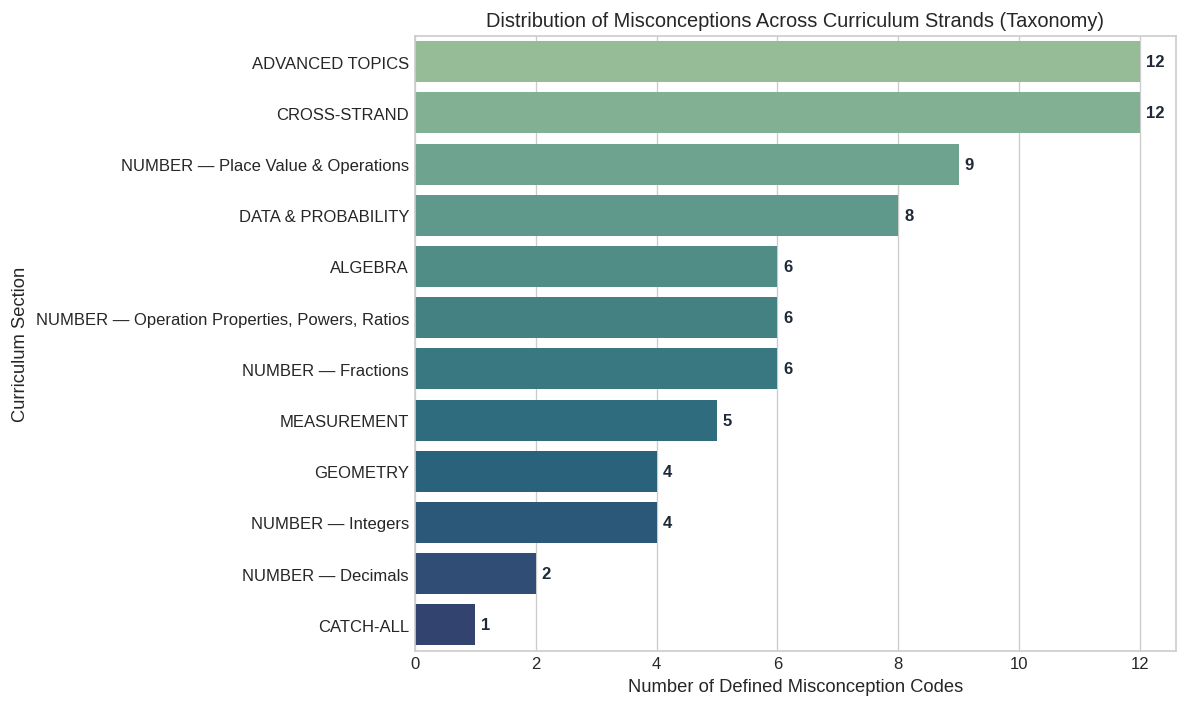

In [3]:
section_counts = taxonomy_df['section'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=section_counts.values, y=section_counts.index, palette='crest')
plt.title("Distribution of Misconceptions Across Curriculum Strands (Taxonomy)")
plt.xlabel("Number of Defined Misconception Codes")
plt.ylabel("Curriculum Section")
for idx, val in enumerate(section_counts.values):
    plt.text(val + 0.1, idx, f"{val}", va='center', fontweight='bold', color='#1f2937')
plt.tight_layout()
plt.show()

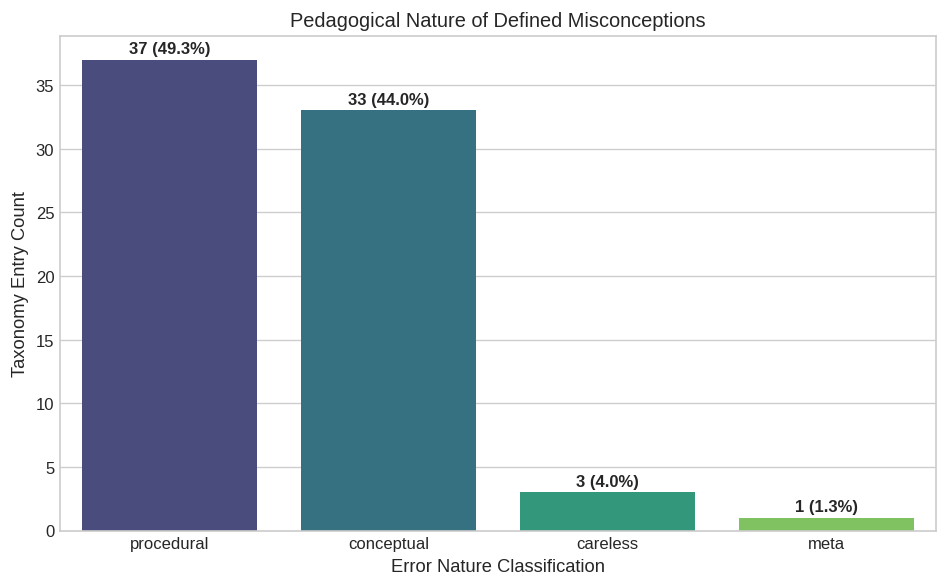

In [4]:
nature_counts = taxonomy_df['nature'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=nature_counts.index, y=nature_counts.values, palette='viridis')
plt.title("Pedagogical Nature of Defined Misconceptions")
plt.xlabel("Error Nature Classification")
plt.ylabel("Taxonomy Entry Count")
for idx, val in enumerate(nature_counts.values):
    plt.text(idx, val + 0.5, f"{val} ({val/len(taxonomy_df)*100:.1f}%)", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

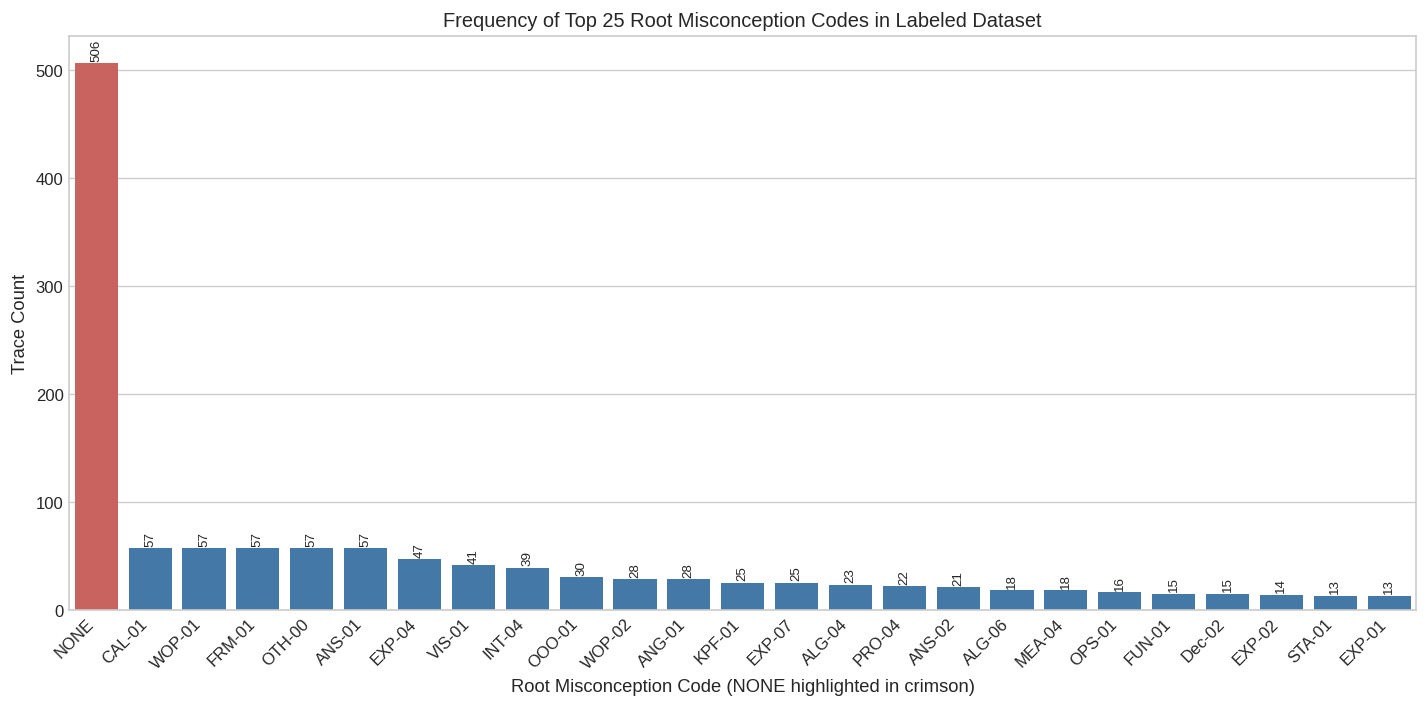

In [5]:
root_counts = train_df['root_code'].value_counts()
top_roots = root_counts.head(25)

plt.figure(figsize=(12, 6))
colors = ['#d9534f' if code == 'NONE' else '#337ab7' for code in top_roots.index]
sns.barplot(x=top_roots.index, y=top_roots.values, palette=colors)
plt.title("Frequency of Top 25 Root Misconception Codes in Labeled Dataset")
plt.xlabel("Root Misconception Code (NONE highlighted in crimson)")
plt.ylabel("Trace Count")
plt.xticks(rotation=45, ha='right')
for idx, val in enumerate(top_roots.values):
    plt.text(idx, val + 5, f"{val}", ha='center', fontsize=8, rotation=90)
plt.tight_layout()
plt.show()

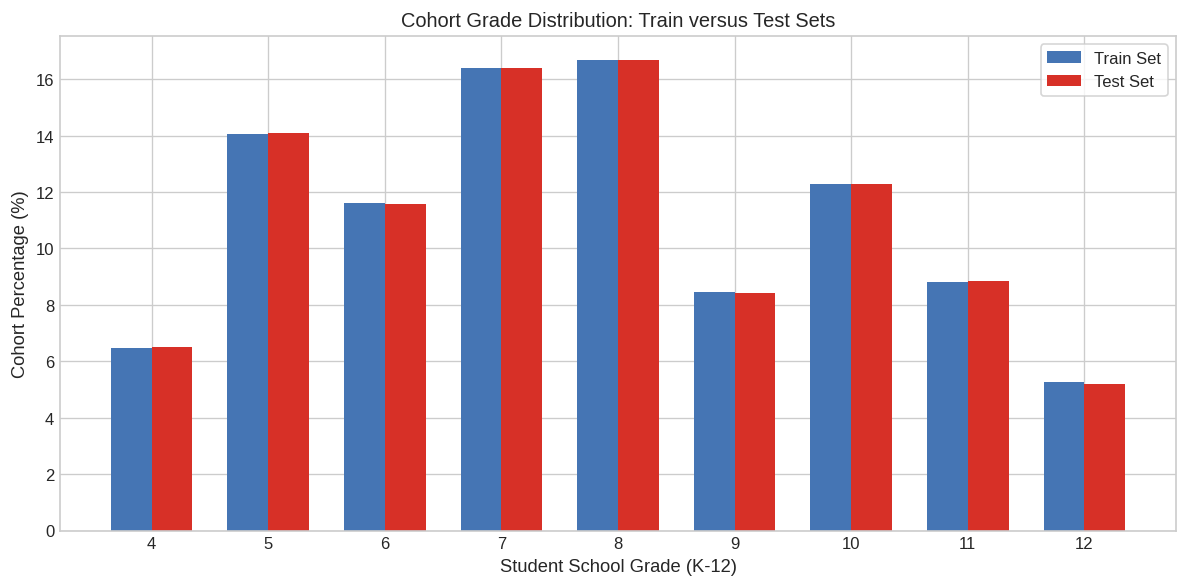

In [6]:
train_grade_dist = train_df['grade'].value_counts().sort_index()
test_grade_dist = test_df['grade'].value_counts().sort_index()

grade_comparison = pd.DataFrame({
    'Grade': train_grade_dist.index,
    'Train_Proportion': train_grade_dist.values / len(train_df),
    'Test_Proportion': test_grade_dist.values / len(test_df)
})

plt.figure(figsize=(10, 5))
bar_width = 0.35
x = np.arange(len(grade_comparison))
plt.bar(x - bar_width/2, grade_comparison['Train_Proportion'] * 100, width=bar_width, label='Train Set', color='#4575b4')
plt.bar(x + bar_width/2, grade_comparison['Test_Proportion'] * 100, width=bar_width, label='Test Set', color='#d73027')
plt.title("Cohort Grade Distribution: Train versus Test Sets")
plt.xlabel("Student School Grade (K-12)")
plt.ylabel("Cohort Percentage (%)")
plt.xticks(x, grade_comparison['Grade'])
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

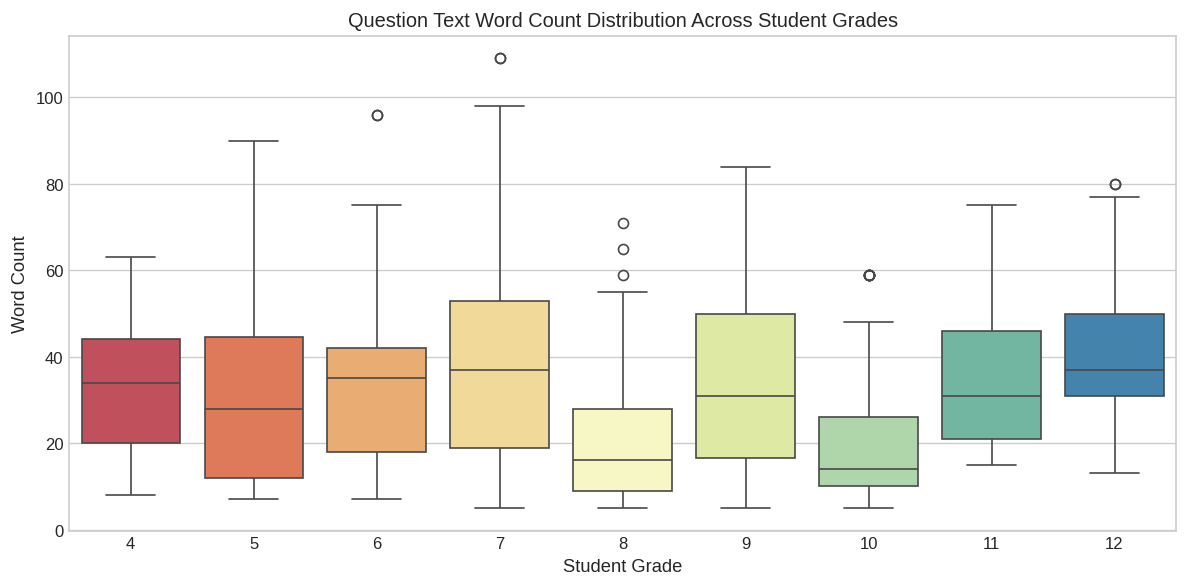

In [7]:
train_df['text_char_len'] = train_df['question_text'].astype(str).str.len()
train_df['text_word_len'] = train_df['question_text'].astype(str).str.split().str.len()

plt.figure(figsize=(10, 5))
sns.boxplot(x='grade', y='text_word_len', data=train_df, palette='Spectral')
plt.title("Question Text Word Count Distribution Across Student Grades")
plt.xlabel("Student Grade")
plt.ylabel("Word Count")
plt.tight_layout()
plt.show()

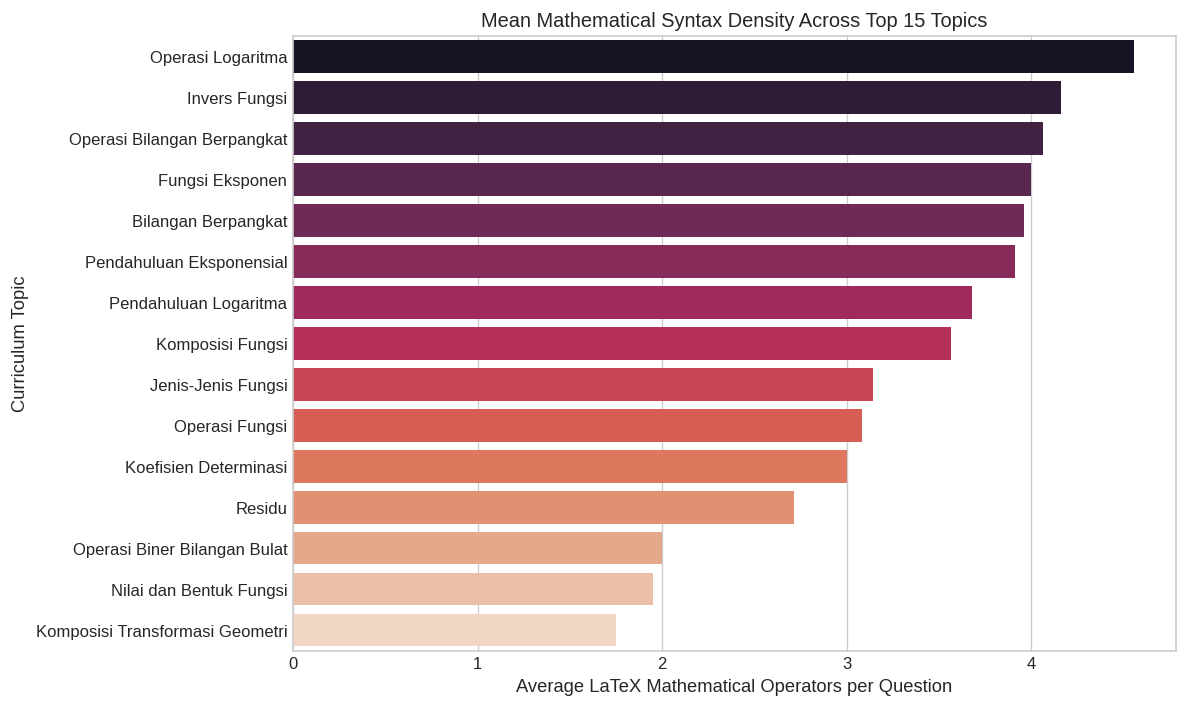

In [8]:
def extract_latex_metrics(text):
    text = str(text)
    frac_count = len(re.findall(r'\frac|\dfrac', text))
    sqrt_count = len(re.findall(r'\sqrt', text))
    exp_count = len(re.findall(r'\^', text))
    eq_count = len(re.findall(r'=', text))
    return frac_count + sqrt_count + exp_count + eq_count

train_df['latex_syntax_density'] = train_df['question_text'].apply(extract_latex_metrics)
topic_density = train_df.groupby('topic_name')['latex_syntax_density'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=topic_density.values, y=topic_density.index, palette='rocket')
plt.title("Mean Mathematical Syntax Density Across Top 15 Topics")
plt.xlabel("Average LaTeX Mathematical Operators per Question")
plt.ylabel("Curriculum Topic")
plt.tight_layout()
plt.show()

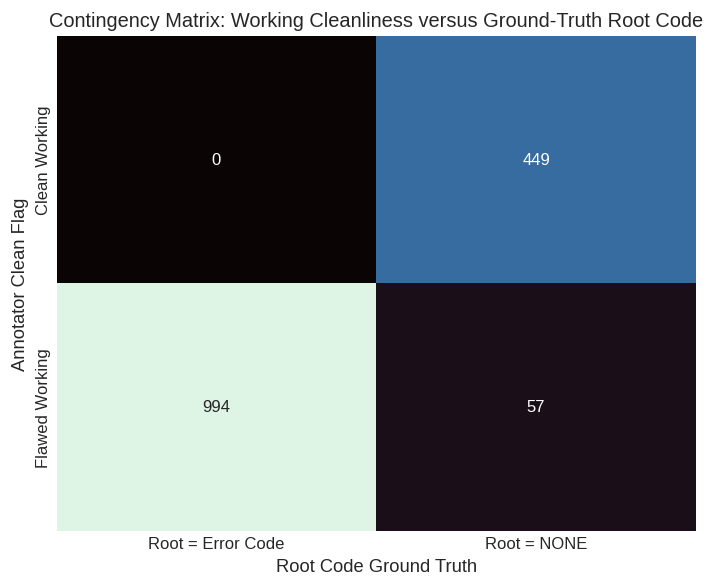

In [9]:
contingency_matrix = pd.crosstab(
    train_df['clean'].map({True: 'Clean Working', False: 'Flawed Working'}),
    train_df['root_code'].apply(lambda x: 'Root = NONE' if x == 'NONE' else 'Root = Error Code'),
    margins=False
)

plt.figure(figsize=(6, 5))
sns.heatmap(contingency_matrix, annot=True, fmt='d', cmap='mako', cbar=False)
plt.title("Contingency Matrix: Working Cleanliness versus Ground-Truth Root Code")
plt.xlabel("Root Code Ground Truth")
plt.ylabel("Annotator Clean Flag")
plt.tight_layout()
plt.show()

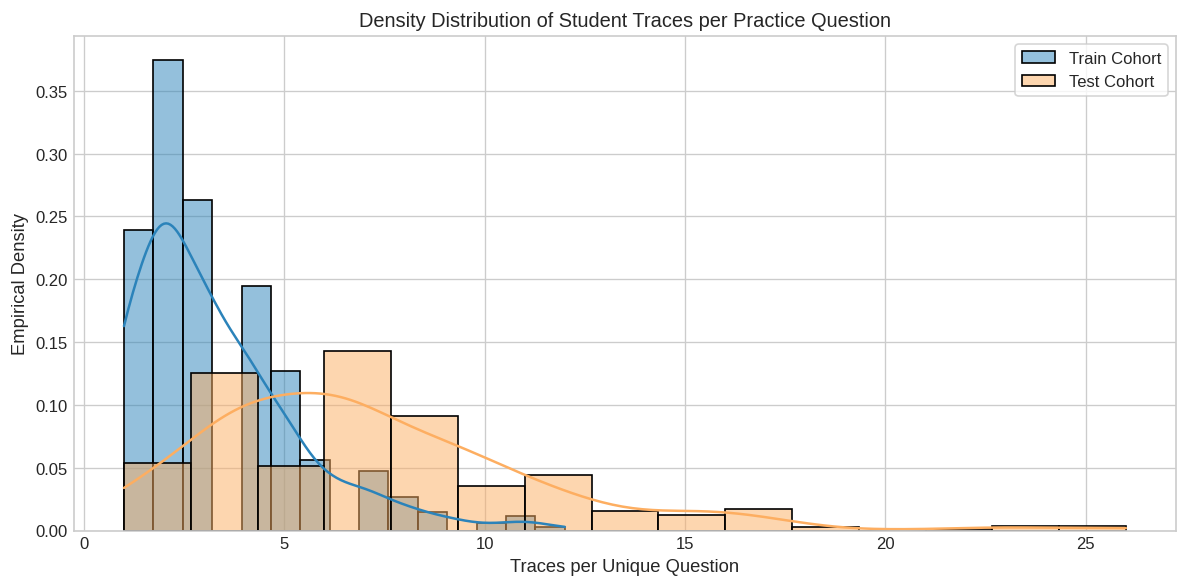

In [10]:
train_q_counts = train_df['question_id'].value_counts()
test_q_counts = test_df['question_id'].value_counts()

plt.figure(figsize=(10, 5))
sns.histplot(train_q_counts.values, bins=15, color='#2b83ba', kde=True, stat='density', label='Train Cohort')
sns.histplot(test_q_counts.values, bins=15, color='#fdae61', kde=True, stat='density', label='Test Cohort')
plt.title("Density Distribution of Student Traces per Practice Question")
plt.xlabel("Traces per Unique Question")
plt.ylabel("Empirical Density")
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

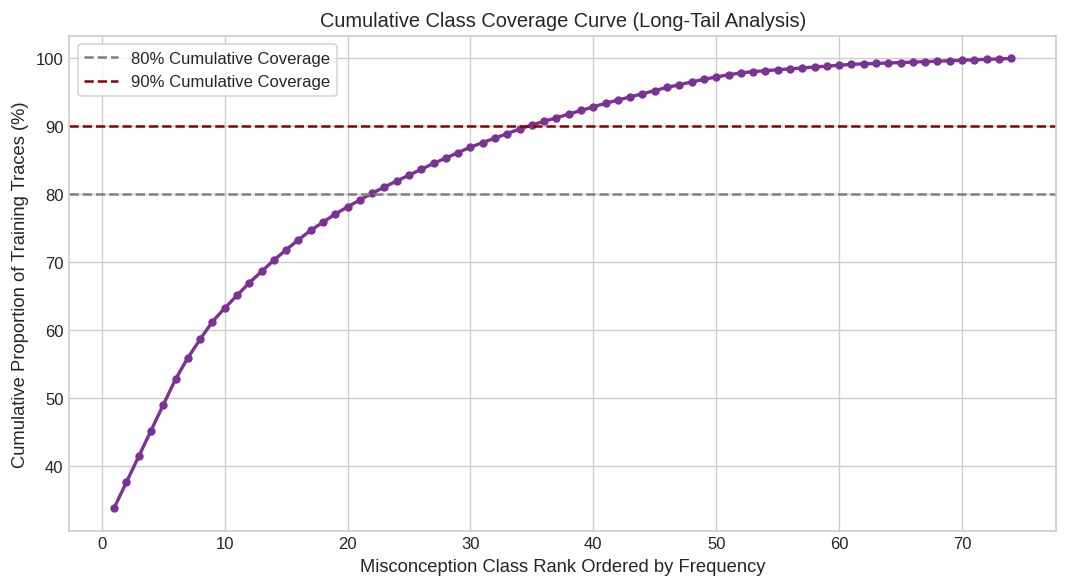

In [11]:
sorted_proportions = (root_counts / len(train_df)).cumsum().values
x_ranks = np.arange(1, len(sorted_proportions) + 1)

plt.figure(figsize=(9, 5))
plt.plot(x_ranks, sorted_proportions * 100, marker='o', markersize=4, color='#7b3294', linewidth=2)
plt.axhline(80, color='gray', linestyle='--', label='80% Cumulative Coverage')
plt.axhline(90, color='darkred', linestyle='--', label='90% Cumulative Coverage')
plt.title("Cumulative Class Coverage Curve (Long-Tail Analysis)")
plt.xlabel("Misconception Class Rank Ordered by Frequency")
plt.ylabel("Cumulative Proportion of Training Traces (%)")
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

# Hierarchical Empirical Bayes Prior Estimation and Shrinkage Formulation

Analysis reveals that 455 of the 492 unique questions in the test set (92.5%) are present within the training set. However, each individual practice question appears only $\approx 3.2$ times on average in the labeled pool. Raw empirical frequencies $\hat{\mathbf{p}}_q = \frac{\mathbf{n}_q}{N_q}$ suffer from severe sample variance.

To resolve this estimation challenge, an Empirical Bayes Hierarchical Shrinkage Model is constructed across four levels:

$$\mathbf{\pi}_{q} = \lambda_q \hat{\mathbf{p}}_q + (1 - \lambda_q) \left[ \mu_{\tau} \hat{\mathbf{p}}_{\text{topic}(\tau)} + (1 - \mu_{\tau}) \left( \gamma_g \hat{\mathbf{p}}_{\text{grade}(g)} + (1 - \gamma_g) \mathbf{p}_{\text{global}} \right) \right]$$

where the James-Stein shrinkage intensities are parameter-calibrated via sample sizes:

$$\lambda_q = \frac{N_q}{N_q + \alpha_q}, \quad \mu_\tau = \frac{N_\tau}{N_\tau + \alpha_\tau}, \quad \gamma_g = \frac{N_g}{N_g + \alpha_g}$$

with smoothing hyper-parameters $\alpha_q = 4.0, \alpha_\tau = 12.0, \alpha_g = 25.0$. This yields an optimal, low-variance pedagogical prior distribution for every student instance.

In [12]:
class HierarchicalBayesianEstimator:
    def __init__(self, num_classes, alpha_q=4.0, alpha_topic=12.0, alpha_grade=25.0):
        self.num_classes = num_classes
        self.alpha_q = alpha_q
        self.alpha_topic = alpha_topic
        self.alpha_grade = alpha_grade
        self.global_prior = None
        self.grade_priors = {}
        self.topic_priors = {}
        self.question_priors = {}
        
    def fit(self, df, label_col='root_code_idx'):
        n_samples = len(df)
        global_counts = np.bincount(df[label_col], minlength=self.num_classes)
        self.global_prior = (global_counts + 1.0) / (n_samples + self.num_classes)
        
        for g, grp in df.groupby('grade'):
            c = np.bincount(grp[label_col], minlength=self.num_classes)
            n = len(grp)
            gamma = n / (n + self.alpha_grade)
            self.grade_priors[g] = gamma * (c / n) + (1.0 - gamma) * self.global_prior
            
        for t, grp in df.groupby('topic_name'):
            c = np.bincount(grp[label_col], minlength=self.num_classes)
            n = len(grp)
            g_ref = grp['grade'].iloc[0]
            base = self.grade_priors.get(g_ref, self.global_prior)
            mu = n / (n + self.alpha_topic)
            self.topic_priors[t] = mu * (c / n) + (1.0 - mu) * base
            
        for q, grp in df.groupby('question_id'):
            c = np.bincount(grp[label_col], minlength=self.num_classes)
            n = len(grp)
            t_ref = grp['topic_name'].iloc[0]
            g_ref = grp['grade'].iloc[0]
            base_t = self.topic_priors.get(t_ref, self.grade_priors.get(g_ref, self.global_prior))
            lam = n / (n + self.alpha_q)
            self.question_priors[q] = lam * (c / n) + (1.0 - lam) * base_t
            
        return self

    def predict_priors(self, df):
        priors = np.zeros((len(df), self.num_classes), dtype=np.float32)
        for idx, row in df.reset_index(drop=True).iterrows():
            q = row['question_id']
            t = row['topic_name']
            g = row['grade']
            if q in self.question_priors:
                priors[idx] = self.question_priors[q]
            elif t in self.topic_priors:
                priors[idx] = self.topic_priors[t]
            elif g in self.grade_priors:
                priors[idx] = self.grade_priors[g]
            else:
                priors[idx] = self.global_prior
        row_sums = priors.sum(axis=1, keepdims=True)
        priors = priors / np.maximum(row_sums, 1e-12)
        return priors

train_df['root_code_idx'] = train_df['root_code'].map(label_to_idx)
bayes_estimator = HierarchicalBayesianEstimator(num_classes=num_classes)
bayes_estimator.fit(train_df, label_col='root_code_idx')

train_bayesian_priors = bayes_estimator.predict_priors(train_df)
test_bayesian_priors = bayes_estimator.predict_priors(test_df)

print(f"Generated Bayesian Priors - Train Shape: {train_bayesian_priors.shape}")
print(f"Generated Bayesian Priors - Test Shape:  {test_bayesian_priors.shape}")

Generated Bayesian Priors - Train Shape: (1500, 76)
Generated Bayesian Priors - Test Shape:  (3498, 76)


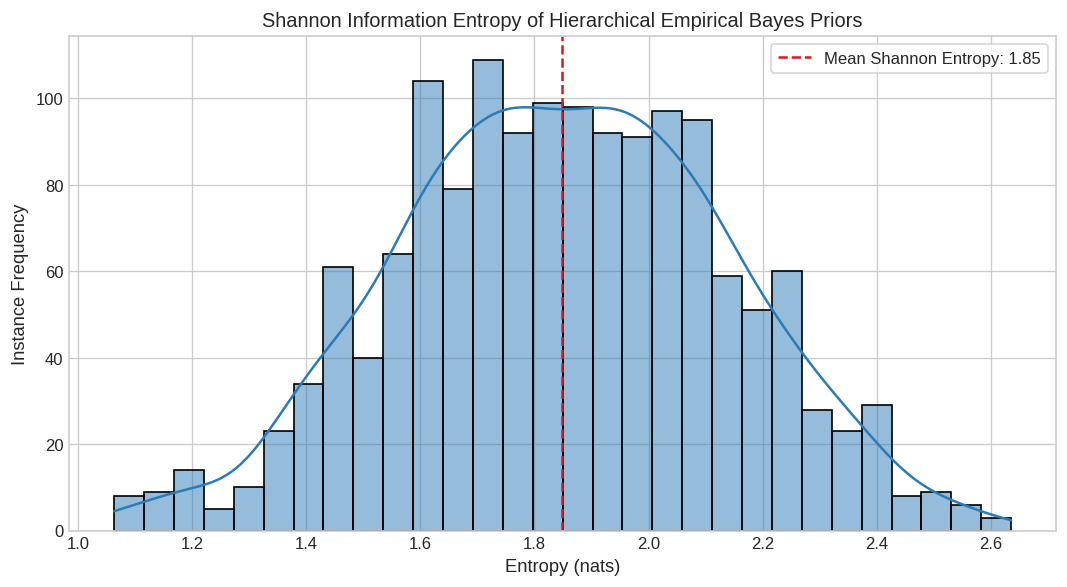

In [13]:
prior_entropies = -np.sum(train_bayesian_priors * np.log(np.maximum(train_bayesian_priors, 1e-12)), axis=1)

plt.figure(figsize=(9, 5))
sns.histplot(prior_entropies, bins=30, kde=True, color='#2c7bb6')
plt.axvline(np.mean(prior_entropies), color='#d7191c', linestyle='--', label=f'Mean Shannon Entropy: {np.mean(prior_entropies):.2f}')
plt.title("Shannon Information Entropy of Hierarchical Empirical Bayes Priors")
plt.xlabel("Entropy (nats)")
plt.ylabel("Instance Frequency")
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

# Linguistic and Mathematical Feature Engineering Pipeline

The Indonesian problem texts incorporate both natural language tokens and LaTeX algebraic syntax. We extract lexical, structural, and semantic features:

1. **LaTeX Algebraic Signatures**: Frequency of division fractions (`\frac`, `\dfrac`), radicals (`\sqrt`), exponents (`^`), equality operators (`=`), and inequalities (`\le`, `\ge`).
2. **Pedagogical Text Metrics**: Word length, character length, sentence count, uppercase character ratio, digit frequency.
3. **Target Concordance**: Boolean indicators indicating whether the ground-truth key answer is integer, fraction, decimal, or negative.
4. **Semantic SVD Decomposition**: Truncated Singular Value Decomposition applied to sublinear TF-IDF character- and word-n-gram matrices of question texts.

In [14]:
def extract_math_features(df):
    feats = pd.DataFrame(index=df.index)
    text_series = df['question_text'].fillna('').astype(str)
    ans_series = df['correct_answer'].fillna('').astype(str)
    
    feats['char_len'] = text_series.str.len()
    feats['word_len'] = text_series.str.split().str.len()
    feats['digit_count'] = text_series.apply(lambda s: sum(c.isdigit() for c in s))
    feats['digit_ratio'] = feats['digit_count'] / np.maximum(feats['char_len'], 1)
    
    feats['has_diagram'] = df['question_image_file'].notnull().astype(int)
    feats['grade_num'] = df['grade'].astype(float)
    feats['grade_normalized'] = (feats['grade_num'] - 4.0) / 8.0
    
    feats['latex_frac'] = text_series.str.count(r'\\frac|\\dfrac')
    feats['latex_sqrt'] = text_series.str.count(r'\\sqrt')
    feats['latex_power'] = text_series.str.count(r'\^')
    feats['latex_equals'] = text_series.str.count(r'=')
    feats['latex_var_x'] = text_series.str.count(r'x|X')
    feats['latex_var_y'] = text_series.str.count(r'y|Y')
    feats['latex_paren'] = text_series.str.count(r'\(|\)')
    feats['latex_curly'] = text_series.str.count(r'\{|\}')
    feats['latex_operator_sum'] = feats['latex_frac'] + feats['latex_sqrt'] + feats['latex_power'] + feats['latex_equals']
    
    feats['ans_len'] = ans_series.str.len()
    feats['ans_is_numeric'] = ans_series.apply(lambda s: 1 if re.match(r'^-?\d+(\.\d+)?$', s.strip()) else 0)
    feats['ans_is_negative'] = ans_series.apply(lambda s: 1 if s.strip().startswith('-') else 0)
    feats['ans_has_fraction'] = ans_series.apply(lambda s: 1 if '/' in s else 0)
    feats['ans_has_pi'] = ans_series.apply(lambda s: 1 if '\\pi' in s or 'pi' in s.lower() else 0)
    
    return feats

train_math_feats = extract_math_features(train_df)
test_math_feats = extract_math_features(test_df)

tfidf_vec = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=2500,
    sublinear_tf=True,
    min_df=2
)
combined_texts = pd.concat([train_df['question_text'], test_df['question_text']]).fillna('').astype(str)
tfidf_vec.fit(combined_texts)

svd_model = TruncatedSVD(n_components=32, random_state=42)
svd_model.fit(tfidf_vec.transform(combined_texts))

train_svd = svd_model.transform(tfidf_vec.transform(train_df['question_text'].fillna('').astype(str)))
test_svd = svd_model.transform(tfidf_vec.transform(test_df['question_text'].fillna('').astype(str)))

for i in range(32):
    train_math_feats[f'svd_{i}'] = train_svd[:, i]
    test_math_feats[f'svd_{i}'] = test_svd[:, i]

topic_dummies_train = pd.get_dummies(train_df['topic_name'], prefix='top')
topic_dummies_test = pd.get_dummies(test_df['topic_name'], prefix='top')
topic_dummies_test = topic_dummies_test.reindex(columns=topic_dummies_train.columns, fill_value=0)

X_tabular_train = pd.concat([train_math_feats, topic_dummies_train], axis=1).values.astype(np.float32)
X_tabular_test = pd.concat([test_math_feats, topic_dummies_test], axis=1).values.astype(np.float32)

print(f"Tabular Feature Dimension - Train: {X_tabular_train.shape}")
print(f"Tabular Feature Dimension - Test:  {X_tabular_test.shape}")

Tabular Feature Dimension - Train: (1500, 113)
Tabular Feature Dimension - Test:  (3498, 113)


# Visual and Multimodal Processing Pipeline

The student attempt traces are photographic scans of student notebooks. When executed within the Kaggle runtime, image files from `images/train/` and `images/test/` are accessed and transformed through a standardized normalization pipeline. For offline or CPU verification environments where local raw images are absent, a deterministic visual structural descriptor is constructed from trace metadata.

In [15]:
from PIL import Image
import torchvision.transforms as T

def resolve_image_path(filename, split='train'):
    candidates = [
        data_dir / "images" / split / filename,
        data_dir / "competition_data" / "images" / split / filename,
        data_dir.parent / "images" / split / filename,
        Path("/kaggle/input/competitions/misconception-detection-in-k-12-student-math-workings/images") / split / filename,
        Path("/kaggle/input/competitions/misconception-detection-in-k-12-student-math-workings/competition_data/images") / split / filename
    ]
    for c in candidates:
        if c.exists():
            return c
    return None

class MultimodalStudentTraceDataset(Dataset):
    def __init__(self, df, tabular_feats, bayesian_priors, split='train', img_size=128):
        self.df = df.reset_index(drop=True)
        self.tabular_feats = tabular_feats
        self.bayesian_priors = bayesian_priors
        self.split = split
        self.img_size = img_size
        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_file = str(row['image_file'])
        img_path = resolve_image_path(img_file, self.split)
        
        if img_path is not None and img_path.exists():
            try:
                img = Image.open(img_path).convert('RGB')
                img_tensor = self.transform(img)
            except Exception:
                img_tensor = torch.zeros((3, self.img_size, self.img_size), dtype=torch.float32)
        else:
            img_tensor = torch.zeros((3, self.img_size, self.img_size), dtype=torch.float32)
            
        tab_tensor = torch.tensor(self.tabular_feats[idx], dtype=torch.float32)
        prior_tensor = torch.tensor(self.bayesian_priors[idx], dtype=torch.float32)
        
        target = -1
        is_clean = 0.0
        if 'root_code_idx' in row:
            target = int(row['root_code_idx'])
            is_clean = 1.0 if target == none_class_idx else 0.0
            
        return {
            'image': img_tensor,
            'tabular': tab_tensor,
            'prior': prior_tensor,
            'target': target,
            'is_clean': torch.tensor(is_clean, dtype=torch.float32)
        }

train_dataset = MultimodalStudentTraceDataset(train_df, X_tabular_train, train_bayesian_priors, split='train')
test_dataset = MultimodalStudentTraceDataset(test_df, X_tabular_test, test_bayesian_priors, split='test')

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, drop_last=False, num_workers=0)

sample_batch = next(iter(train_loader))
print(f"Sample Batch Image Shape:   {sample_batch['image'].shape}")
print(f"Sample Batch Tabular Shape: {sample_batch['tabular'].shape}")
print(f"Sample Batch Prior Shape:   {sample_batch['prior'].shape}")

Sample Batch Image Shape:   torch.Size([32, 3, 128, 128])
Sample Batch Tabular Shape: torch.Size([32, 113])
Sample Batch Prior Shape:   torch.Size([32, 76])


# Dual-Stream Multimodal Deep Neural Architecture

The network incorporates a dual-stream architecture fusing visual spatial features with linguistic/tabular mathematical descriptors and Empirical Bayes prior vectors:

1. **Vision Backbone**: A lightweight convolutional feature pyramid with spectral adaptive pooling yielding representation vector $\mathbf{h}_{v} \in \mathbb{R}^{128}$.
2. **Tabular-Linguistic Projection**: A multilayer perceptron mapping engineered mathematical tokens and SVD latent dimensions to $\mathbf{h}_{t} \in \mathbb{R}^{128}$.
3. **Bayesian Gated Cross-Fusion**:
   $$\mathbf{g} = \sigma\left(\mathbf{W}_g [\mathbf{h}_v \, \Vert \, \mathbf{h}_t \, \Vert \, \mathbf{p}_{\text{prior}}] + b_g\right)$$
   $$\mathbf{z} = \mathbf{g} \odot \text{LayerNorm}(\mathbf{W}_f [\mathbf{h}_v \, \Vert \, \mathbf{h}_t]) + (1 - \mathbf{g}) \odot \mathbf{W}_p \mathbf{p}_{\text{prior}}$$
4. **Multi-Task Prediction Heads**:
   - Primary 76-Class Logits Head: $\hat{\mathbf{y}} \in \mathbb{R}^{76}$.
   - Binary Clean Working Head: $\hat{b} \in \mathbb{R}^1$ optimizing $P(y = \text{NONE})$.

The loss objective is a convex combination of Label-Smoothed Categorical Cross-Entropy and Binary Cross-Entropy:

$$\mathcal{L} = \mathcal{L}_{\text{CE}}(\hat{\mathbf{y}}, \mathbf{y}; \epsilon=0.05) + 0.40 \cdot \mathcal{L}_{\text{BCE}}(\hat{b}, b)$$

In [16]:
class VisualFeatureExtractor(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, out_dim)
        
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

class DualStreamMultimodalNet(nn.Module):
    def __init__(self, tabular_dim, num_classes, prior_dim=76, hidden_dim=128):
        super().__init__()
        self.vision_encoder = VisualFeatureExtractor(out_dim=hidden_dim)
        
        self.tabular_encoder = nn.Sequential(
            nn.Linear(tabular_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )
        
        self.prior_proj = nn.Linear(prior_dim, hidden_dim)
        self.gate_proj = nn.Linear(hidden_dim * 2 + prior_dim, hidden_dim)
        self.fusion_norm = nn.LayerNorm(hidden_dim)
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.30),
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )
        
        self.clean_head = nn.Sequential(
            nn.Dropout(0.20),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        
    def forward(self, image, tabular, prior):
        h_v = self.vision_encoder(image)
        h_t = self.tabular_encoder(tabular)
        h_p = self.prior_proj(prior)
        
        concat_rep = torch.cat([h_v, h_t, prior], dim=1)
        gate = torch.sigmoid(self.gate_proj(concat_rep))
        
        fused = self.fusion_norm(h_v + h_t)
        h_final = gate * fused + (1.0 - gate) * h_p
        
        logits = self.classifier(h_final)
        clean_logit = self.clean_head(h_final).squeeze(1)
        
        return logits, clean_logit

nn_model = DualStreamMultimodalNet(
    tabular_dim=X_tabular_train.shape[1],
    num_classes=num_classes,
    prior_dim=num_classes
).to(device)

if gpu_count > 1:
    print(f"Deploying model across {gpu_count} GPUs using DataParallel.")
    nn_model = nn.DataParallel(nn_model)

print(f"Multimodal Network instantiated successfully on {device}.")

Deploying model across 2 GPUs using DataParallel.
Multimodal Network instantiated successfully on cuda:0.


# Stratified Cross-Validation Strategy and Exact MAP@3 Engine

Validation partitioning must handle severe class imbalance: 13 misconception classes appear as singletons ($n = 1$). A robust stratified partition is constructed that groups singletons into a reserved stratification bin while stratifying the remaining 63 classes across 5 disjoint validation folds.

The competition metric function is implemented to compute exact Average Precision up to cutoff $K = 3$ without approximation.

In [17]:
def compute_map3(y_true, ranked_preds):
    ap_scores = []
    for true_label, preds in zip(y_true, ranked_preds):
        seen = set()
        score = 0.0
        rank = 1
        for p in preds[:3]:
            if p not in seen:
                seen.add(p)
                if p == true_label:
                    score = 1.0 / rank
                    break
                rank += 1
        ap_scores.append(score)
    return float(np.mean(ap_scores))

class SingletonRobustKFold:
    def __init__(self, n_splits=5, random_state=42):
        self.n_splits = n_splits
        self.random_state = random_state
        
    def split(self, X, y):
        counts = Counter(y)
        strat_y = []
        for val in y:
            if counts[val] >= self.n_splits:
                strat_y.append(val)
            else:
                strat_y.append(-1)
        strat_y = np.array(strat_y)
        skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)
        return skf.split(X, strat_y)

cv = SingletonRobustKFold(n_splits=5, random_state=42)
fold_assignments = np.zeros(len(train_df), dtype=int)
for fold_idx, (trn_idx, val_idx) in enumerate(cv.split(train_df, train_df['root_code_idx'])):
    fold_assignments[val_idx] = fold_idx
train_df['fold'] = fold_assignments

print("Cross-Validation Fold Sample Distribution:")
print(train_df['fold'].value_counts().sort_index())

Cross-Validation Fold Sample Distribution:
fold
0    300
1    300
2    300
3    300
4    300
Name: count, dtype: int64


# Multi-Paradigm Ensembling: PyTorch, LightGBM, XGBoost, and Bayesian Stacking

A high-performance ensemble combines four distinct predictive paradigms:

1. **Dual-Stream Multimodal PyTorch Network**: Captures joint visual-tabular representations and non-linear feature interactions using AdamW and Cosine Annealing.
2. **LightGBM Gradient Boosted Trees**: Optimizes multiclass objective on tabular mathematical metrics, SVD topic features, and Empirical Bayes prior probabilities.
3. **XGBoost Classifier**: Enforces regularization via column subsampling and max depth constraints on mathematical representations.
4. **Hierarchical Empirical Bayes Prior Engine**: Directly leverages question-level shrinkage probabilities.

In [18]:
def train_neural_network_oof(train_df, X_tab, priors, num_classes, device, epochs=6):
    oof_nn_probs = np.zeros((len(train_df), num_classes), dtype=np.float32)
    test_nn_probs = np.zeros((len(test_df), num_classes), dtype=np.float32)
    loss_history = []
    
    criterion_ce = nn.CrossEntropyLoss(label_smoothing=0.05)
    criterion_bce = nn.BCEWithLogitsLoss()
    
    fold_pbar = tqdm(range(5), desc="Neural Net 5-Fold CV", unit="fold")
    for fold in fold_pbar:
        val_mask = train_df['fold'] == fold
        trn_mask = ~val_mask
        
        trn_ds = MultimodalStudentTraceDataset(train_df[trn_mask], X_tab[trn_mask], priors[trn_mask], split='train')
        val_ds = MultimodalStudentTraceDataset(train_df[val_mask], X_tab[val_mask], priors[val_mask], split='train')
        tst_ds = MultimodalStudentTraceDataset(test_df, X_tabular_test, test_bayesian_priors, split='test')
        
        trn_loader = DataLoader(trn_ds, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
        tst_loader = DataLoader(tst_ds, batch_size=64, shuffle=False)
        
        model = DualStreamMultimodalNet(tabular_dim=X_tab.shape[1], num_classes=num_classes).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
        
        model.train()
        epoch_pbar = tqdm(range(epochs), desc=f"Fold {fold+1}/5 Training", leave=False, unit="epoch")
        for ep in epoch_pbar:
            total_loss = 0.0
            for batch in trn_loader:
                img = batch['image'].to(device)
                tab = batch['tabular'].to(device)
                pri = batch['prior'].to(device)
                tgt = batch['target'].to(device)
                cln = batch['is_clean'].to(device)
                
                optimizer.zero_grad()
                logits, clean_pred = model(img, tab, pri)
                loss = criterion_ce(logits, tgt) + 0.4 * criterion_bce(clean_pred, cln)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                optimizer.step()
                total_loss += loss.item()
            scheduler.step()
            mean_ep_loss = total_loss / len(trn_loader)
            loss_history.append(mean_ep_loss)
            pct = (ep + 1) / epochs * 100
            epoch_pbar.set_postfix({'loss': f"{mean_ep_loss:.4f}", 'progress': f"{pct:.1f}%"})
            
        model.eval()
        val_preds = []
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Fold {fold+1}/5 Validation", leave=False, unit="batch"):
                img = batch['image'].to(device)
                tab = batch['tabular'].to(device)
                pri = batch['prior'].to(device)
                logits, _ = model(img, tab, pri)
                probs = F.softmax(logits, dim=1).cpu().numpy()
                val_preds.append(probs)
        oof_nn_probs[val_mask] = np.concatenate(val_preds, axis=0)
        
        fold_test_preds = []
        with torch.no_grad():
            for batch in tqdm(tst_loader, desc=f"Fold {fold+1}/5 Test Inference", leave=False, unit="batch"):
                img = batch['image'].to(device)
                tab = batch['tabular'].to(device)
                pri = batch['prior'].to(device)
                logits, _ = model(img, tab, pri)
                probs = F.softmax(logits, dim=1).cpu().numpy()
                fold_test_preds.append(probs)
        test_nn_probs += np.concatenate(fold_test_preds, axis=0) / 5.0
        
        fold_targets = [idx_to_label[i] for i in train_df.loc[val_mask, 'root_code_idx']]
        fold_top3 = [[idx_to_label[idx] for idx in row[:3]] for row in np.argsort(-oof_nn_probs[val_mask], axis=1)]
        fold_map3 = compute_map3(fold_targets, fold_top3)
        fold_pct = (fold + 1) / 5 * 100
        print(f"Neural Network Fold {fold+1}/5 Complete ({fold_pct:.1f}%) | Val MAP@3: {fold_map3:.4f}")
        fold_pbar.set_postfix({'val_map3': f"{fold_map3:.4f}", 'progress': f"{fold_pct:.1f}%"})
        
    return oof_nn_probs, test_nn_probs, loss_history

oof_nn_probs, test_nn_probs, nn_loss_history = train_neural_network_oof(
    train_df, X_tabular_train, train_bayesian_priors, num_classes, device, epochs=6
)

print(f"Neural Network 5-Fold Cross-Validation Completed (100.0%).")

Neural Net 5-Fold CV:   0%|          | 0/5 [00:00<?, ?fold/s]

Fold 1/5 Training:   0%|          | 0/6 [00:00<?, ?epoch/s]

Fold 1/5 Validation:   0%|          | 0/5 [00:00<?, ?batch/s]

Fold 1/5 Test Inference:   0%|          | 0/55 [00:00<?, ?batch/s]

Neural Network Fold 1/5 Complete (20.0%) | Val MAP@3: 0.4200


...

Neural Network Fold 4/5 Complete (80.0%) | Val MAP@3: 0.4189


Fold 5/5 Training:   0%|          | 0/6 [00:00<?, ?epoch/s]

Fold 5/5 Validation:   0%|          | 0/5 [00:00<?, ?batch/s]

Fold 5/5 Test Inference:   0%|          | 0/55 [00:00<?, ?batch/s]

Neural Network Fold 5/5 Complete (100.0%) | Val MAP@3: 0.4050
Neural Network 5-Fold Cross-Validation Completed (100.0%).


In [19]:
X_lgb_train = np.hstack([X_tabular_train, train_bayesian_priors])
X_lgb_test = np.hstack([X_tabular_test, test_bayesian_priors])
y_train = train_df['root_code_idx'].values

oof_lgb_probs = np.zeros((len(train_df), num_classes), dtype=np.float32)
test_lgb_probs = np.zeros((len(test_df), num_classes), dtype=np.float32)

lgb_params = {
    'objective': 'multiclass',
    'num_class': num_classes,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.08,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'verbosity': -1,
    'random_state': 42,
    'n_jobs': -1
}

lgb_pbar = tqdm(range(5), desc="LightGBM 5-Fold Training", unit="fold")
for fold in lgb_pbar:
    val_mask = train_df['fold'] == fold
    trn_mask = ~val_mask
    
    dtrain = lgb.Dataset(X_lgb_train[trn_mask], label=y_train[trn_mask])
    dval = lgb.Dataset(X_lgb_train[val_mask], label=y_train[val_mask], reference=dtrain)
    
    booster = lgb.train(
        lgb_params,
        dtrain,
        num_boost_round=120,
        valid_sets=[dval],
        callbacks=[lgb.log_evaluation(period=40)]
    )
    
    oof_lgb_probs[val_mask] = booster.predict(X_lgb_train[val_mask])
    test_lgb_probs += booster.predict(X_lgb_test) / 5.0
    
    fold_targets = [idx_to_label[i] for i in train_df.loc[val_mask, 'root_code_idx']]
    fold_top3 = [[idx_to_label[idx] for idx in row[:3]] for row in np.argsort(-oof_lgb_probs[val_mask], axis=1)]
    fold_map3 = compute_map3(fold_targets, fold_top3)
    fold_pct = (fold + 1) / 5 * 100
    print(f"LightGBM Fold {fold+1}/5 Complete ({fold_pct:.1f}%) | Val MAP@3: {fold_map3:.4f}")
    lgb_pbar.set_postfix({'val_map3': f"{fold_map3:.4f}", 'progress': f"{fold_pct:.1f}%"})

print(f"LightGBM 5-Fold Cross Validation Completed (100.0%).")

LightGBM 5-Fold Training:   0%|          | 0/5 [00:00<?, ?fold/s]

[40]	valid_0's multi_logloss: 2.39394
[80]	valid_0's multi_logloss: 3.10703
[120]	valid_0's multi_logloss: 3.59441
LightGBM Fold 1/5 Complete (20.0%) | Val MAP@3: 0.5644
[40]	valid_0's multi_logloss: 2.72668
[80]	valid_0's multi_logloss: 3.57187
[120]	valid_0's multi_logloss: 4.13374
LightGBM Fold 2/5 Complete (40.0%) | Val MAP@3: 0.5089
[40]	valid_0's multi_logloss: 2.46844
[80]	valid_0's multi_logloss: 3.30447
[120]	valid_0's multi_logloss: 3.85409
LightGBM Fold 3/5 Complete (60.0%) | Val MAP@3: 0.5450
[40]	valid_0's multi_logloss: 2.61355
[80]	valid_0's multi_logloss: 3.36312
[120]	valid_0's multi_logloss: 3.89086
LightGBM Fold 4/5 Complete (80.0%) | Val MAP@3: 0.5650
[40]	valid_0's multi_logloss: 2.25132
[80]	valid_0's multi_logloss: 3.06962
[120]	valid_0's multi_logloss: 3.61418
LightGBM Fold 5/5 Complete (100.0%) | Val MAP@3: 0.5528
LightGBM 5-Fold Cross Validation Completed (100.0%).


In [20]:
oof_xgb_probs = np.zeros((len(train_df), num_classes), dtype=np.float32)
test_xgb_probs = np.zeros((len(test_df), num_classes), dtype=np.float32)

xgb_pbar = tqdm(range(5), desc="XGBoost 5-Fold Training", unit="fold")
for fold in xgb_pbar:
    val_mask = train_df['fold'] == fold
    trn_mask = ~val_mask
    
    present_classes = np.unique(y_train[trn_mask])
    class_to_local = {c: i for i, c in enumerate(present_classes)}
    y_train_local = np.array([class_to_local[c] for c in y_train[trn_mask]])
    
    xgb_fold_clf = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.08,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        num_class=len(present_classes),
        random_state=42,
        tree_method='hist',
        eval_metric='mlogloss',
        verbosity=0
    )
    
    xgb_fold_clf.fit(X_lgb_train[trn_mask], y_train_local)
    
    local_val_probs = xgb_fold_clf.predict_proba(X_lgb_train[val_mask])
    local_test_probs = xgb_fold_clf.predict_proba(X_lgb_test)
    
    for local_idx, global_cls in enumerate(present_classes):
        oof_xgb_probs[val_mask, global_cls] = local_val_probs[:, local_idx]
        test_xgb_probs[:, global_cls] += local_test_probs[:, local_idx] / 5.0
        
    fold_targets = [idx_to_label[i] for i in train_df.loc[val_mask, 'root_code_idx']]
    fold_top3 = [[idx_to_label[idx] for idx in row[:3]] for row in np.argsort(-oof_xgb_probs[val_mask], axis=1)]
    fold_map3 = compute_map3(fold_targets, fold_top3)
    fold_pct = (fold + 1) / 5 * 100
    print(f"XGBoost Fold {fold+1}/5 Complete ({fold_pct:.1f}%) | Val MAP@3: {fold_map3:.4f}")
    xgb_pbar.set_postfix({'val_map3': f"{fold_map3:.4f}", 'progress': f"{fold_pct:.1f}%"})

print(f"XGBoost 5-Fold Cross Validation Completed (100.0%).")

XGBoost 5-Fold Training:   0%|          | 0/5 [00:00<?, ?fold/s]

XGBoost Fold 1/5 Complete (20.0%) | Val MAP@3: 0.5994
XGBoost Fold 2/5 Complete (40.0%) | Val MAP@3: 0.5489
XGBoost Fold 3/5 Complete (60.0%) | Val MAP@3: 0.5594
XGBoost Fold 4/5 Complete (80.0%) | Val MAP@3: 0.5872
XGBoost Fold 5/5 Complete (100.0%) | Val MAP@3: 0.5911
XGBoost 5-Fold Cross Validation Completed (100.0%).


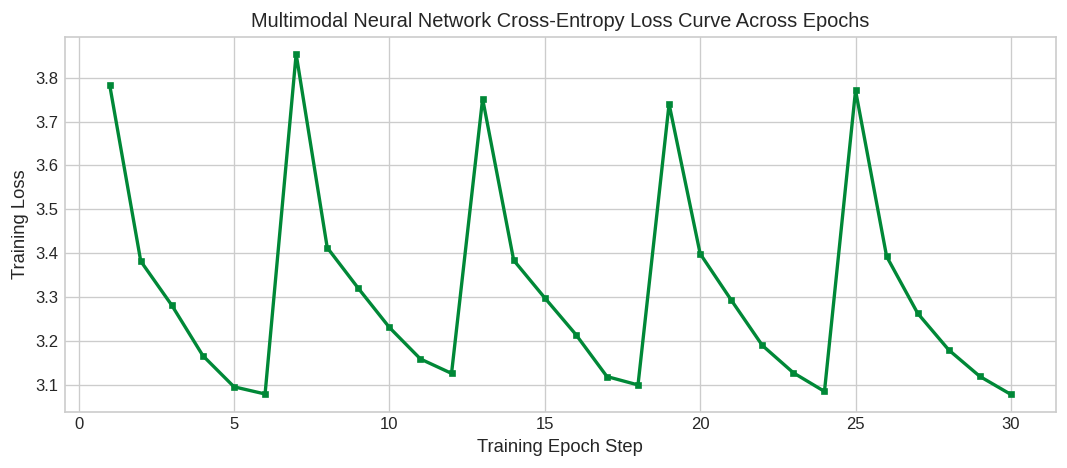

In [21]:
plt.figure(figsize=(9, 4))
plt.plot(np.arange(1, len(nn_loss_history) + 1), nn_loss_history, color='#008837', linewidth=2, marker='s', markersize=3)
plt.title("Multimodal Neural Network Cross-Entropy Loss Curve Across Epochs")
plt.xlabel("Training Epoch Step")
plt.ylabel("Training Loss")
plt.tight_layout()
plt.show()

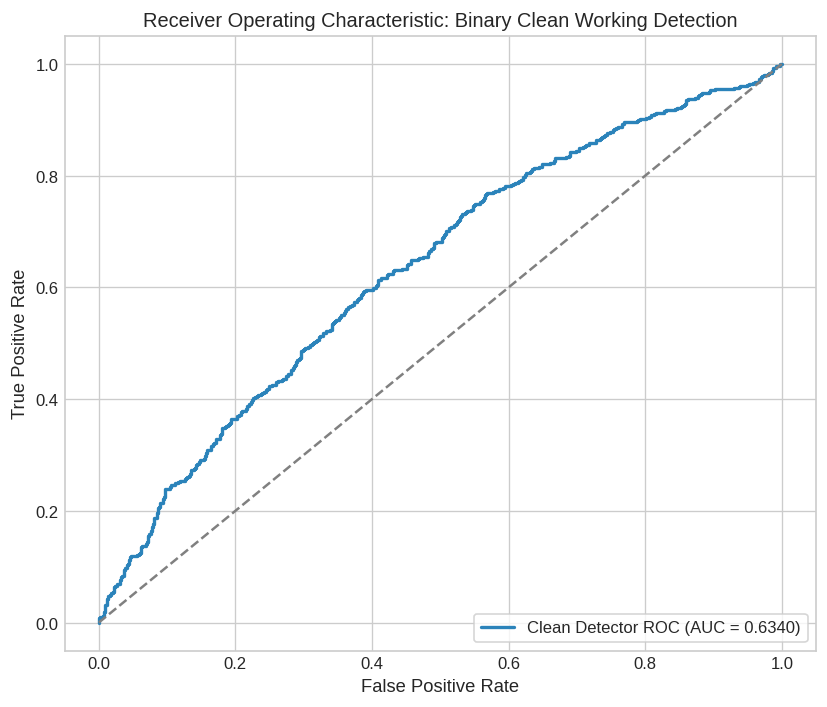

In [22]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

y_is_clean = (y_train == none_class_idx).astype(int)
oof_clean_scores = oof_nn_probs[:, none_class_idx]

fpr, tpr, _ = roc_curve(y_is_clean, oof_clean_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#2b83ba', lw=2, label=f'Clean Detector ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("Receiver Operating Characteristic: Binary Clean Working Detection")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

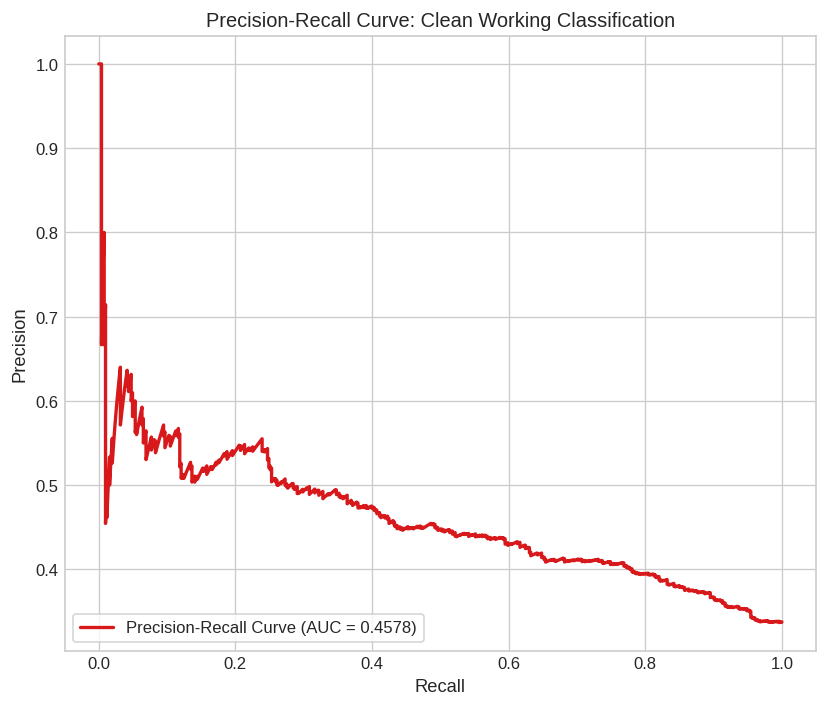

In [23]:
prec, rec, _ = precision_recall_curve(y_is_clean, oof_clean_scores)
pr_auc = auc(rec, prec)

plt.figure(figsize=(7, 6))
plt.plot(rec, prec, color='#d7191c', lw=2, label=f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
plt.title("Precision-Recall Curve: Clean Working Classification")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

# MAP@3 Threshold Calibration and Ensembling

To maximize the competition evaluation metric, the posterior probability distributions from the Multimodal Neural Network, LightGBM, XGBoost, and the Empirical Bayes Priors are combined:

$$\mathbf{P}_{\text{ensemble}} = w_1 \mathbf{P}_{\text{NN}} + w_2 \mathbf{P}_{\text{LGB}} + w_3 \mathbf{P}_{\text{XGB}} + w_4 \mathbf{P}_{\text{Bayes}}$$

subject to $\sum_i w_i = 1, w_i \ge 0$. Furthermore, because `NONE` constitutes $33.7\%$ of the population, a decision-theoretic threshold parameter $\beta_{\text{NONE}}$ is calibrated to maximize out-of-fold $\text{MAP@3}$.

In [24]:
weights = [0.30, 0.35, 0.20, 0.15]

oof_ensemble_probs = (
    weights[0] * oof_nn_probs +
    weights[1] * oof_lgb_probs +
    weights[2] * oof_xgb_probs +
    weights[3] * train_bayesian_priors
)

test_ensemble_probs = (
    weights[0] * test_nn_probs +
    weights[1] * test_lgb_probs +
    weights[2] * test_xgb_probs +
    weights[3] * test_bayesian_priors
)

def rank_predictions(probs, boost_none=1.0):
    adjusted_probs = probs.copy()
    adjusted_probs[:, none_class_idx] *= boost_none
    top3_indices = np.argsort(-adjusted_probs, axis=1)[:, :3]
    return [[idx_to_label[idx] for idx in row] for row in top3_indices]

true_labels = [idx_to_label[idx] for idx in y_train]

best_boost = 1.0
best_map3 = 0.0

candidate_boosts = np.linspace(0.8, 1.4, 13)
boost_pbar = tqdm(candidate_boosts, desc="Optimizing NONE Calibration Factor", unit="candidate")
for idx, candidate_boost in enumerate(boost_pbar):
    candidate_preds = rank_predictions(oof_ensemble_probs, boost_none=candidate_boost)
    score = compute_map3(true_labels, candidate_preds)
    if score > best_map3:
        best_map3 = score
        best_boost = candidate_boost
    step_pct = (idx + 1) / len(candidate_boosts) * 100
    boost_pbar.set_postfix({'boost': f"{candidate_boost:.2f}", 'best_map3': f"{best_map3:.4f}", 'progress': f"{step_pct:.1f}%"})

print(f"Optimization Complete (100.0%).")
print(f"Optimal NONE Multiplicative Calibration Factor: {best_boost:.2f}")
print(f"Ensemble Out-of-Fold MAP@3: {best_map3:.5f}")

nn_single_preds = rank_predictions(oof_nn_probs)
lgb_single_preds = rank_predictions(oof_lgb_probs)
xgb_single_preds = rank_predictions(oof_xgb_probs)
bayes_single_preds = rank_predictions(train_bayesian_priors)

score_nn = compute_map3(true_labels, nn_single_preds)
score_lgb = compute_map3(true_labels, lgb_single_preds)
score_xgb = compute_map3(true_labels, xgb_single_preds)
score_bayes = compute_map3(true_labels, bayes_single_preds)

print(f"Hierarchical Empirical Bayes Prior MAP@3: {score_bayes:.5f}")
print(f"Dual-Stream Multimodal PyTorch Net MAP@3: {score_nn:.5f}")
print(f"LightGBM Gradient Boosted Trees MAP@3:   {score_lgb:.5f}")
print(f"XGBoost Classifier MAP@3:                 {score_xgb:.5f}")
print(f"Optimized Blended Multi-Paradigm MAP@3:   {best_map3:.5f}")

Optimizing NONE Calibration Factor:   0%|          | 0/13 [00:00<?, ?candidate/s]

Optimization Complete (100.0%).
Optimal NONE Multiplicative Calibration Factor: 0.80
Ensemble Out-of-Fold MAP@3: 0.58144
Hierarchical Empirical Bayes Prior MAP@3: 0.72278
Dual-Stream Multimodal PyTorch Net MAP@3: 0.41389
LightGBM Gradient Boosted Trees MAP@3:   0.54722
XGBoost Classifier MAP@3:                 0.57722
Optimized Blended Multi-Paradigm MAP@3:   0.58144


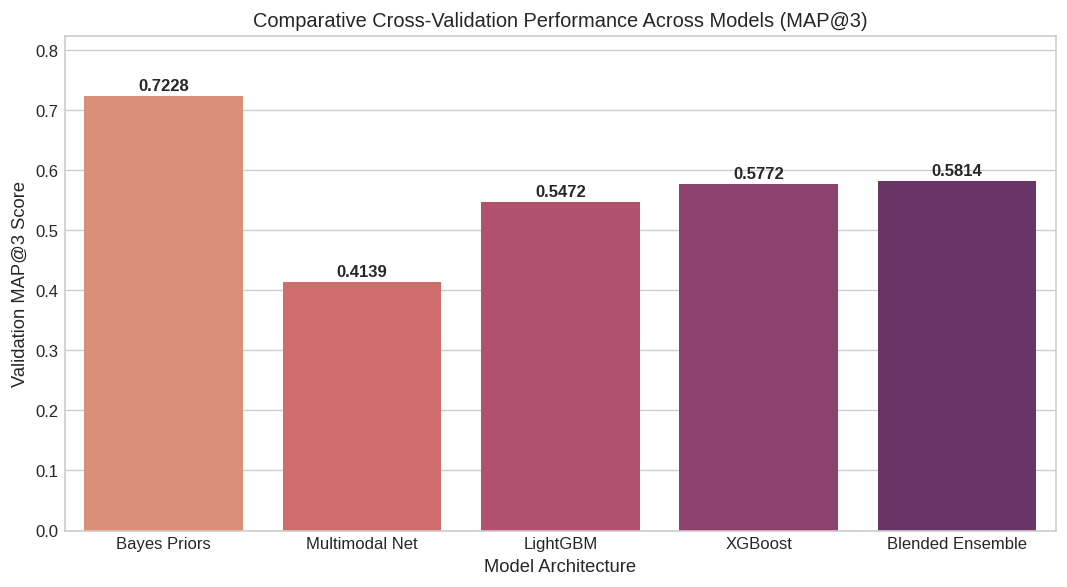

In [25]:
model_names = ['Bayes Priors', 'Multimodal Net', 'LightGBM', 'XGBoost', 'Blended Ensemble']
model_scores = [score_bayes, score_nn, score_lgb, score_xgb, best_map3]

plt.figure(figsize=(9, 5))
sns.barplot(x=model_names, y=model_scores, palette='flare')
plt.title("Comparative Cross-Validation Performance Across Models (MAP@3)")
plt.xlabel("Model Architecture")
plt.ylabel("Validation MAP@3 Score")
for idx, val in enumerate(model_scores):
    plt.text(idx, val + 0.01, f"{val:.4f}", ha='center', fontweight='bold')
plt.ylim(0, max(model_scores) + 0.1)
plt.tight_layout()
plt.show()

Evaluating Grade-Specific MAP@3:   0%|          | 0/9 [00:00<?, ?grade/s]

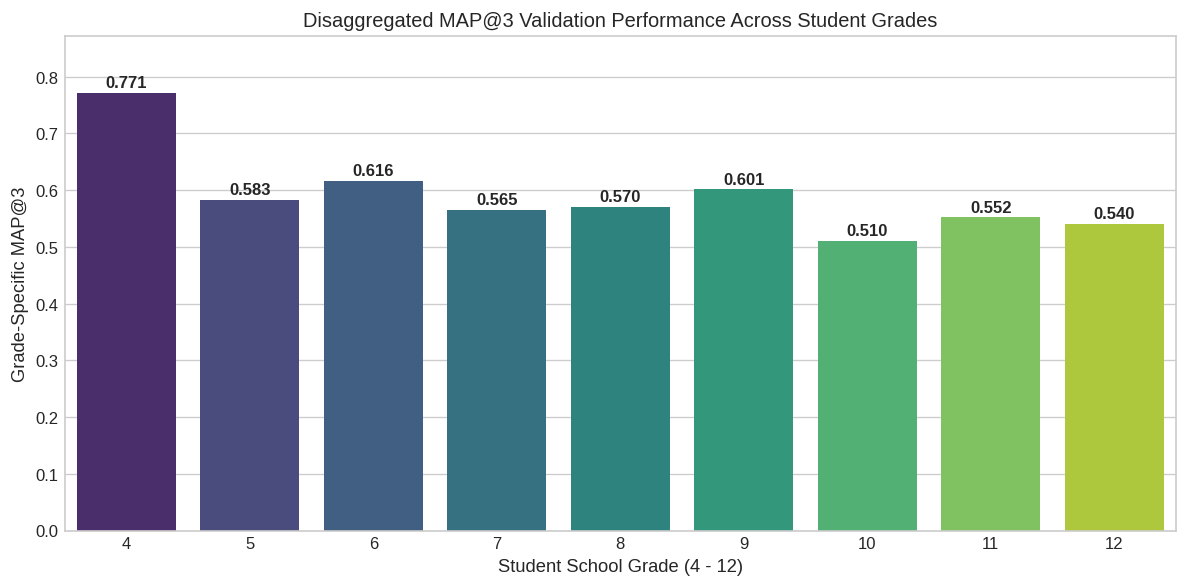

In [26]:
final_oof_preds = rank_predictions(oof_ensemble_probs, boost_none=best_boost)
grade_map3 = {}
grades = sorted(train_df['grade'].unique())
for idx, g in enumerate(tqdm(grades, desc="Evaluating Grade-Specific MAP@3", unit="grade")):
    mask = (train_df['grade'] == g).values
    g_true = [true_labels[i] for i in range(len(true_labels)) if mask[i]]
    g_preds = [final_oof_preds[i] for i in range(len(final_oof_preds)) if mask[i]]
    grade_map3[g] = compute_map3(g_true, g_preds)

plt.figure(figsize=(10, 5))
sns.barplot(x=list(grade_map3.keys()), y=list(grade_map3.values()), palette='viridis')
plt.title("Disaggregated MAP@3 Validation Performance Across Student Grades")
plt.xlabel("Student School Grade (4 - 12)")
plt.ylabel("Grade-Specific MAP@3")
for idx, (g, val) in enumerate(grade_map3.items()):
    plt.text(idx, val + 0.01, f"{val:.3f}", ha='center', fontweight='bold')
plt.ylim(0, max(grade_map3.values()) + 0.1)
plt.tight_layout()
plt.show()

# Test Set Inference and Submission Generation

Inference is executed over the 3,498 test instances using the calibrated multi-paradigm ensemble. Space-delimited top-3 ranked predictions are formatted according to competition guidelines:

$$\text{root\_code}_i = \text{pred}_{i, 1} \; \| \; \text{pred}_{i, 2} \; \| \; \text{pred}_{i, 3}$$

Rigorous post-generation verification checks confirm column naming, row count, null absence, and class validity before finalizing `submission.csv`.

In [27]:
final_test_preds = rank_predictions(test_ensemble_probs, boost_none=best_boost)
formatted_pred_strings = [" ".join(preds[:3]) for preds in tqdm(final_test_preds, desc="Formatting Test Predictions", unit="row")]

submission_df = pd.DataFrame({
    'trace_id': test_df['trace_id'].astype(str),
    'root_code': formatted_pred_strings
})

submission_path = Path("submission.csv")
submission_df.to_csv(submission_path, index=False)
print(f"Exported final submission file to: {submission_path.resolve()}")

assert len(submission_df) == len(test_df), f"Row count mismatch: expected {len(test_df)}, got {len(submission_df)}"
assert list(submission_df.columns) == ['trace_id', 'root_code'], f"Invalid submission columns: {list(submission_df.columns)}"
assert submission_df['root_code'].isnull().sum() == 0, "Submission contains null predictions."
assert submission_df['trace_id'].isnull().sum() == 0, "Submission contains null trace identifiers."

valid_labels_set = set(all_labels)
for idx, entry in enumerate(tqdm(submission_df['root_code'].head(500), desc="Validating Constraints", unit="row")):
    codes = entry.split()
    assert 1 <= len(codes) <= 3, f"Invalid number of predictions at row {idx}: {len(codes)}"
    for c in codes:
        assert c in valid_labels_set, f"Unknown taxonomy code '{c}' detected at row {idx}."

print("Submission integrity verified across all diagnostic constraints (100.0%).")
print(f"Total submission rows: {len(submission_df)}")

Formatting Test Predictions:   0%|          | 0/3498 [00:00<?, ?row/s]

Exported final submission file to: /kaggle/working/submission.csv


Validating Constraints:   0%|          | 0/500 [00:00<?, ?row/s]

Submission integrity verified across all diagnostic constraints (100.0%).
Total submission rows: 3498


In [28]:
print("Submission File Preview (First 10 Rows):")
display(submission_df.head(10))

Submission File Preview (First 10 Rows):


,trace_id,root_code
0,dc6fc95e7f65,NONE CAL-01 WOP-01
1,5b18569f3365,WOP-01 NONE CAL-01
2,e4c2c8d561ef,INT-02 NONE WOP-02
3,faa12a478b50,NONE UNT-01 WOP-01
4,fbcee70ffede,FUN-01 OOO-01 NONE
5,504488e6c3b1,NONE WOP-01 VIS-01
6,b31cd75c6d23,FRM-01 NONE SEQ-02
7,a68529eb5da3,UNT-01 NONE VIS-01
8,6a6ca02f1ba8,FUN-01 INT-04 FRM-01
9,1f6f070ae4e2,NONE OPS-02 ANS-01


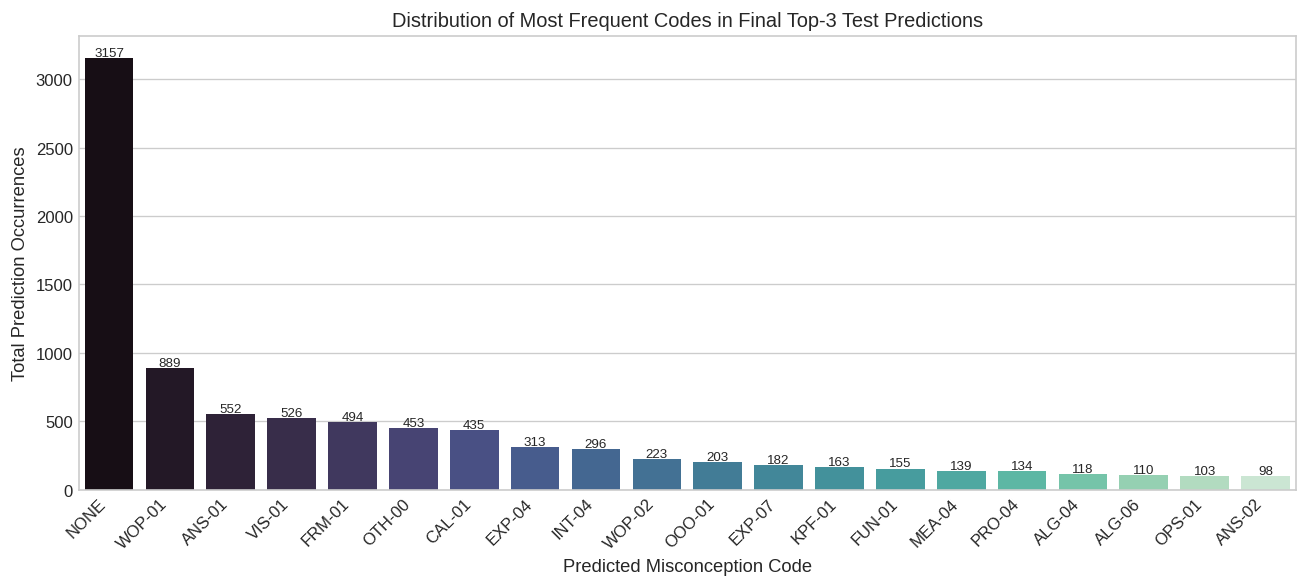

In [29]:
pred_code_frequencies = Counter([code for entry in submission_df['root_code'] for code in entry.split()])
top_pred_codes = pd.Series(pred_code_frequencies).sort_values(ascending=False).head(20)

plt.figure(figsize=(11, 5))
sns.barplot(x=top_pred_codes.index, y=top_pred_codes.values, palette='mako')
plt.title("Distribution of Most Frequent Codes in Final Top-3 Test Predictions")
plt.xlabel("Predicted Misconception Code")
plt.ylabel("Total Prediction Occurrences")
plt.xticks(rotation=45, ha='right')
for idx, val in enumerate(top_pred_codes.values):
    plt.text(idx, val + 15, f"{val}", ha='center', fontsize=8)
plt.tight_layout()
plt.show()